In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
pip install opendatasets

In [31]:
#{"username":"osamaemad18112022","key":"077431ab0445a802e9c7b71e749190e2"}

In [32]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/rahulchavan99/marketing-campaign-dataset')


Skipping, found downloaded files in "./marketing-campaign-dataset" (use force=True to force download)


In [33]:
df=pd.read_csv('/content/marketing-campaign-dataset/Marketing campaign dataset.csv')

##explore data

In [34]:
df.sample(2)

,campaign_item_id,no_of_days,time,ext_service_id,ext_service_name,creative_id,creative_width,creative_height,search_tags,template_id,...,exchange_rate,media_cost_usd,position_in_content,unique_reach,total_reach,search_tag_cat,cmi_currency_code,timezone,weekday_cat,keywords
67639,3219,16,2022-07-20,128,Facebook Ads,13150,300.0,250.0,#Timeless X Style,90.0,...,1,18.719255,NaN,NaN,NaN,Others,AED,Asia/Kolkata,week_day,crystal jewelry
23816,3149,9,2022-10-26,4,Google Ads,5350,300.0,250.0,#Timeless X Style,90.0,...,1,1.865476,NaN,NaN,NaN,Others,AED,Asia/Kolkata,week_day,designer-inspired jewelry


## cleanning data

In [35]:
df = df.drop(columns=['total_reach','max_bid_cpm'])


In [36]:
df['creative_width'].fillna(0,inplace=True)
df['creative_height'].fillna(0,inplace=True)
df['template_id'].fillna(0,inplace=True)

/tmp/ipykernel_694/4003988942.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['creative_width'].fillna(0,inplace=True)
/tmp/ipykernel_694/4003988942.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [37]:
df=df.drop(columns=['position_in_content','unique_reach'])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72612 entries, 0 to 72611
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_item_id     72612 non-null  int64  
 1   no_of_days           72612 non-null  int64  
 2   time                 72612 non-null  object 
 3   ext_service_id       72612 non-null  int64  
 4   ext_service_name     72612 non-null  object 
 5   creative_id          72612 non-null  int64  
 6   creative_width       72612 non-null  float64
 7   creative_height      72612 non-null  float64
 8   search_tags          72612 non-null  object 
 9   template_id          72612 non-null  float64
 10  landing_page         72612 non-null  object 
 11  advertiser_id        72612 non-null  int64  
 12  advertiser_name      72612 non-null  object 
 13  network_id           72612 non-null  int64  
 14  approved_budget      72206 non-null  float64
 15  advertiser_currency  72612 non-null 

## feature engineering

In [39]:
df['ctr']=(df['clicks']/df['impressions'])*100

In [40]:
df['cpm']=(df['media_cost_usd']/df['impressions'])*1000

In [41]:
df['cpc']=df['media_cost_usd']/df['clicks']

In [42]:
df['campaign_item_id']=df['campaign_item_id'].astype(object)

In [55]:
df['space']=df['creative_height']*df['creative_width']

In [56]:
df['ad_size'] = df['creative_width'].astype(str) + 'x' + df['creative_height'].astype(str)

## Campaign Performance Analysis

In [43]:
df['ext_service_name'].unique()

array(['Facebook Ads', 'DV360', 'Google Ads'], dtype=object)

In [44]:
grouped=df.groupby('ext_service_name')[['impressions','clicks','media_cost_usd']].sum()

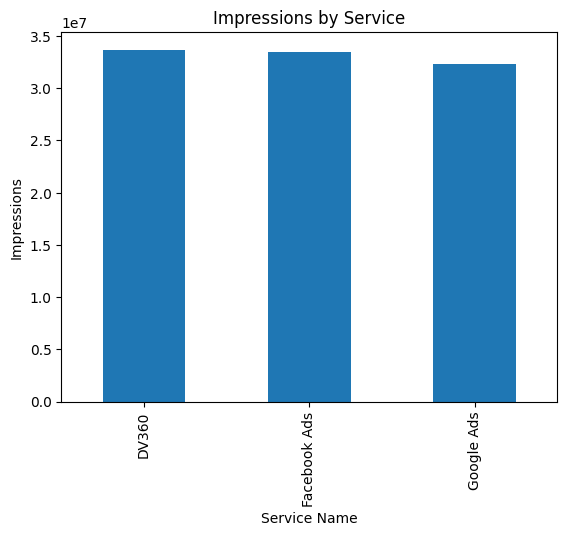

In [47]:

grouped['impressions'].plot(kind='bar')

plt.title('Impressions by Service')
plt.xlabel('Service Name')
plt.ylabel('Impressions')

plt.show()

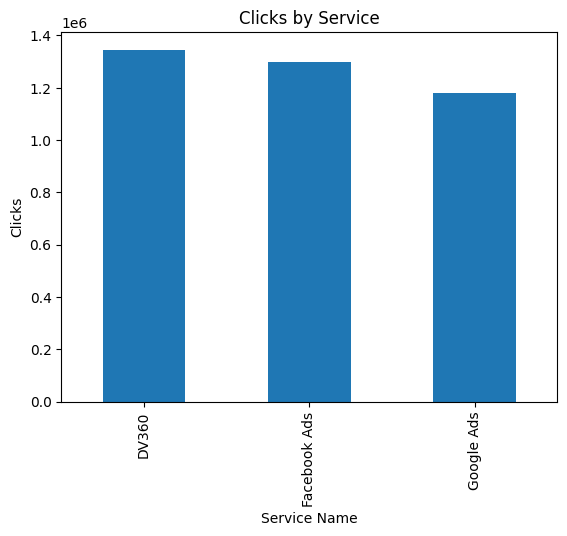

In [48]:
grouped['clicks'].plot(kind='bar')

plt.title('Clicks by Service')
plt.xlabel('Service Name')
plt.ylabel('Clicks')

plt.show()

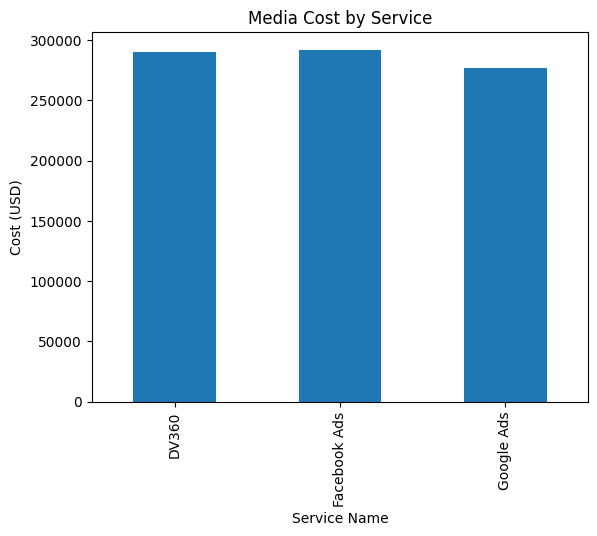

In [50]:
grouped['media_cost_usd'].plot(kind='bar')

plt.title('Media Cost by Service')
plt.xlabel('Service Name')
plt.ylabel('Cost (USD)')

plt.show()

##search tags comration

In [51]:
df['search_tags'].unique()

array(['#The Power of X', '#Be Bold. Be X',
       '#Embrace Your Individuality with X',
       '#The Ultimate Fashion Statement with X',
       '#The X Factor - Fashion for the Fearless', '#Timeless X Style'],
      dtype=object)

In [54]:
df.groupby('channel_name')[['ctr','cpc','campaign_budget_usd','clicks','impressions']].mean()

,ctr,cpc,campaign_budget_usd,clicks,impressions
channel_name,,,,,
Display,1.778162,0.395550,615.548111,53.535198,1356.006576
Mobile,1.751955,0.405329,615.642664,53.533333,1367.954872
Search,1.730576,0.406996,619.678636,50.881363,1376.065863
Social,1.720183,0.396557,616.346313,51.894759,1370.061059
Video,1.744367,0.405400,620.954835,53.628090,1380.695353


## the  most used size

In [57]:
size_counts = df['ad_size'].value_counts()

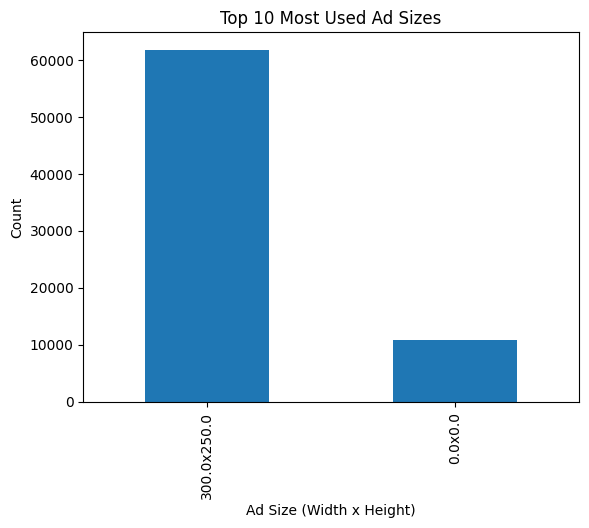

In [58]:
import matplotlib.pyplot as plt

size_counts.head(10).plot(kind='bar')

plt.title('Top 10 Most Used Ad Sizes')
plt.xlabel('Ad Size (Width x Height)')
plt.ylabel('Count')

plt.show()

##budgets and clicks and cpc cpr

In [59]:
df[['campaign_budget_usd','clicks']].corr()

,campaign_budget_usd,clicks
campaign_budget_usd,1.000000,0.561154
clicks,0.561154,1.000000


In [ ]:
df['cpc']

In [63]:
df[['campaign_budget_usd','clicks','cpc','cpm','ctr']].corr()

,campaign_budget_usd,clicks,cpc,cpm,ctr
campaign_budget_usd,1.000000,0.561154,0.067801,0.210055,0.181534
clicks,0.561154,1.000000,-0.037082,0.089493,0.769364
cpc,0.067801,-0.037082,1.000000,0.737222,-0.083180
cpm,0.210055,0.089493,0.737222,1.000000,0.107352
ctr,0.181534,0.769364,-0.083180,0.107352,1.000000


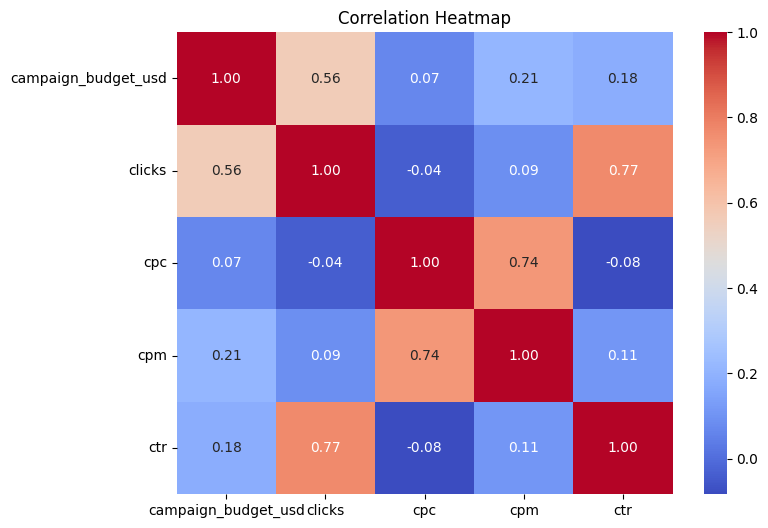

In [64]:
corr = df[['campaign_budget_usd','clicks','cpc','cpm','ctr']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## Time Analysis

In [65]:
clicks_by_time = df.groupby('time')['clicks'].sum()

In [67]:
df['time']

,time
0,2022-05-01
1,2022-05-02
2,2022-05-03
3,2022-05-04
4,2022-05-05
...,...
72607,2022-11-28
72608,2022-11-29
72609,2022-11-30
72610,2022-12-01


In [69]:
df['time'] = pd.to_datetime(df['time'])
clicks_monthly = df.set_index('time').resample('M')['clicks'].sum()


/tmp/ipykernel_694/1974181266.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  clicks_monthly = df.set_index('time').resample('M')['clicks'].sum()


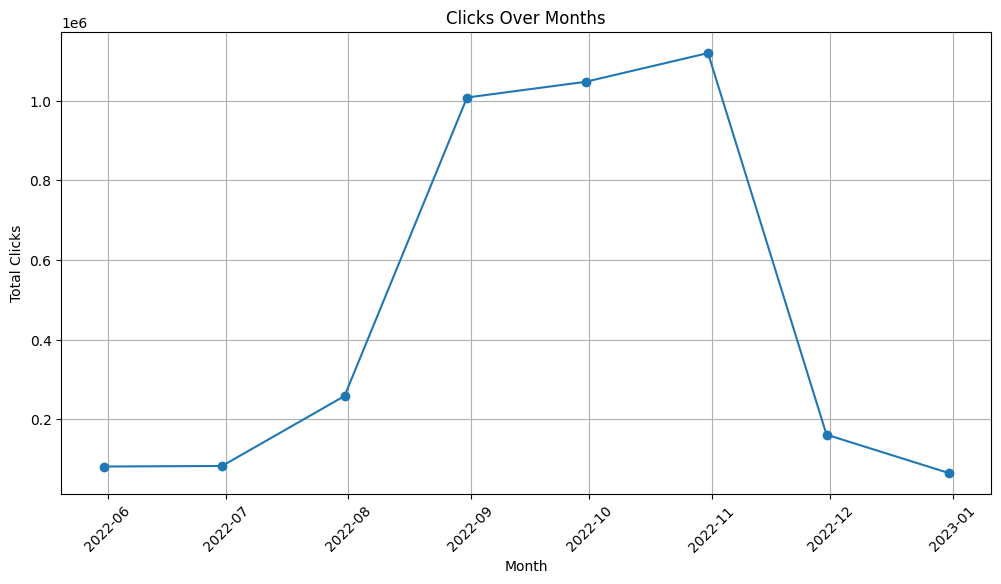

In [70]:
plt.figure(figsize=(12,6))
plt.plot(clicks_monthly.index, clicks_monthly.values, marker='o')

plt.title('Clicks Over Months')
plt.xlabel('Month')
plt.ylabel('Total Clicks')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

##week day compration

In [75]:
grouped_weekday=df.groupby('weekday_cat')[['clicks','impressions']].sum()

In [76]:
percentage_weekday = grouped_weekday.div(grouped_weekday.sum()) * 100

In [77]:
print(percentage_weekday)

                clicks  impressions
weekday_cat                        
week_day     86.224927     85.36567
week_end     13.775073     14.63433


In [80]:
from google.colab import files
df.to_csv('marketing_data.csv', index=False)
files.download('marketing_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
df['cpc'].dtype

dtype('float64')